# ForgeEdge — Market Context Module (Modulo 0)

Questo notebook illustra il **Market Context Module**, il *Modulo 0* della pipeline FORGE.
Gira una volta all'inizio della sessione e arricchisce la KPI Table con due colonne immutabili —
`regime` e `regime_stable` — disponibili a tutti i moduli a valle.

Contenuti:
1. Dati di esempio (solo `close` necessario)
2. Esecuzione base e output (`regime`, `regime_stable`)
3. Finestra EMA decisa dai dati (analisi Hurst / Ornstein-Uhlenbeck)
4. Distribuzione dei regimi
5. `regime_table()` per il join con il dato di origine
6. Modo di taglio: `fixed` vs `balanced` (soglie distribuzionali)
7. Causalità delle soglie: `global` vs `expanding`
8. Coerenza tra timeframe: `window_unit` `bar` vs `day`
9. Visualizzazione del prezzo colorato per regime


## 0. Setup

In [1]:
import sys
sys.path.insert(0, "../src")   # per esecuzione da notebooks/

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from forgedge import MarketContext, MarketContextConfig
from forgedge.market_context import EMAProxyConfig

## 1. Dati di esempio

Il modulo richiede **solo la colonna `close`** (più un riferimento temporale per la
modalità `day`): gli indicatori EMA per stimare il regime vengono calcolati internamente.

Qui generiamo una serie sintetica OHLCV *mean-reverting attorno a un trend lento* — così
compaiono fasi rialziste e ribassiste. In produzione si sostituisce con i propri dati,
es. `pd.read_excel("../data/test1h.xlsx")`.

In [2]:
def make_ohlcv(n=15000, seed=7, freq="1h", start="2023-01-01"):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    mu = np.log(0.5) + 0.45*np.sin(2*np.pi*t/6000) + 0.00008*t   # trend lento su/giù
    x = np.empty(n); x[0] = mu[0]
    for i in range(1, n):                                        # OU verso il trend
        x[i] = x[i-1] + 0.02*(mu[i]-x[i-1]) + rng.normal(0, 0.006)
    close = np.exp(x)
    o = np.r_[close[0], close[:-1]]
    hi = np.maximum(o, close)*(1+np.abs(rng.normal(0, 0.001, n)))
    lo = np.minimum(o, close)*(1-np.abs(rng.normal(0, 0.001, n)))
    return pd.DataFrame({
        "open_dt": pd.date_range(start, periods=n, freq=freq),
        "open": o, "high": hi, "low": lo, "close": close,
        "volume": np.abs(rng.normal(1e6, 2e5, n)),
    })

kpi = make_ohlcv()
print(f"righe: {len(kpi)} | periodo: {kpi.open_dt.iloc[0].date()} -> {kpi.open_dt.iloc[-1].date()}")
kpi.head()

righe: 15000 | periodo: 2023-01-01 -> 2024-09-16


,open_dt,open,high,low,close,volume
0,2023-01-01 00:00:00,0.500000,0.500276,0.499275,0.500000,7.095353e+05
1,2023-01-01 01:00:00,0.500000,0.500526,0.499486,0.500009,1.072625e+06
2,2023-01-01 02:00:00,0.500009,0.501131,0.499501,0.500917,1.321568e+06
3,2023-01-01 03:00:00,0.500917,0.501129,0.499746,0.500092,1.064958e+06
4,2023-01-01 04:00:00,0.500092,0.500606,0.496899,0.497447,7.988627e+05


## 2. Esecuzione base

`MarketContext(kpi).run()` ritorna una **copia** della KPI Table con due colonne aggiunte:

- `regime` — categorical ordinato: `STRONG_BEAR < BEAR < NEUTRAL < BULL < STRONG_BULL`
- `regime_stable` — `True` se il regime è invariato da `stable_window` barre (default 12)

L'input non viene modificato e nessuna colonna EMA intermedia viene scritta.

In [3]:
mc = MarketContext(kpi)
out = mc.run()

print("colonne aggiunte:", sorted(set(out.columns) - set(kpi.columns)))
print("regime dtype:", out["regime"].dtype, "| ordered:", out["regime"].cat.ordered)
out[["open_dt", "close", "regime", "regime_stable"]].iloc[6000:6006]

colonne aggiunte: ['regime', 'regime_stable']
regime dtype: category | ordered: True


,open_dt,close,regime,regime_stable
6000,2023-09-08 00:00:00,0.780739,STRONG_BULL,True
6001,2023-09-08 01:00:00,0.776005,STRONG_BULL,True
6002,2023-09-08 02:00:00,0.777466,STRONG_BULL,True
6003,2023-09-08 03:00:00,0.787739,STRONG_BULL,True
6004,2023-09-08 04:00:00,0.781459,STRONG_BULL,True
6005,2023-09-08 05:00:00,0.784934,STRONG_BULL,True


## 3. Finestra EMA decisa dai dati (Hurst / OU)

Le finestre EMA `fast`/`slow` non sono fisse: il modulo stima l'**half-life del processo
Ornstein-Uhlenbeck** (analisi di Hurst) sulla serie e ne ricava gli span. Se l'half-life
non converge (serie troppo corta o trending) ricade sui fallback `9`/`25`.

`window_resolution` riporta come sono state decise; `get_config()` l'intera configurazione
per la tracciabilità nel report.

In [4]:
import pprint
pprint.pp(mc.window_resolution)
print()
pprint.pp(mc.get_config())

{'source': 'hurst_ou',
 'short_period': 575,
 'long_period': 1322,
 'half_life_bars': 1322.3,
 'n_estimates': 239,
 'unit': 'day',
 'estimation_window_bars': 4032,
 'bar_hours': 1.0}

{'classifier': {'classifier': 'ema_proxy',
                'source_col': 'close',
                'short_period': 575,
                'long_period': 1322,
                'threshold_mode': 'fixed',
                'threshold_basis': 'global',
                'threshold_warmup': 200,
                'thresholds': [0.975, 0.99, 1.01, 1.025],
                'target_distribution': [0.1, 0.2, 0.4, 0.2, 0.1],
                'resolved_thresholds': [0.975, 0.99, 1.01, 1.025],
                'resolved_threshold_mode': 'fixed',
                'resolved_threshold_basis': None,
                'labels': ['STRONG_BEAR',
                           'BEAR',
                           'NEUTRAL',
                           'BULL',
                           'STRONG_BULL']},
 'labels': ['STRONG_BEAR', 'BEAR', 'NEUTRAL'

## 4. Distribuzione dei regimi

In [5]:
mc.distribution()

,n_bars,share
regime,,
STRONG_BEAR,4949,0.3299
BEAR,542,0.0361
NEUTRAL,890,0.0593
BULL,598,0.0399
STRONG_BULL,8021,0.5347


## 5. `regime_table()` per il join

Accessor compatto `[timestamp, regime, regime_stable]`, pronto per il merge sul dato di origine.
La chiave timestamp è inferita (indice/colonna datetime, default `open_dt`).

In [6]:
rt = mc.regime_table()
print("colonne:", list(rt.columns), "| shape:", rt.shape)

joined = kpi.merge(rt, on="open_dt", how="left")
print("join:", joined.shape, "| regime non-null:", joined["regime"].notna().all())
rt.head()

colonne: ['open_dt', 'regime', 'regime_stable'] | shape: (15000, 3)
join: (15000, 8) | regime non-null: True


,open_dt,regime,regime_stable
0,2023-01-01 00:00:00,NEUTRAL,False
1,2023-01-01 01:00:00,NEUTRAL,False
2,2023-01-01 02:00:00,NEUTRAL,False
3,2023-01-01 03:00:00,NEUTRAL,False
4,2023-01-01 04:00:00,NEUTRAL,False


## 6. Modo di taglio: `fixed` vs `balanced`

Con soglie **fisse** (`threshold_mode="fixed"`, default) la distribuzione dei regimi non è
controllata e su un asset direzionale può collassare sugli estremi. Con
`threshold_mode="balanced"` le soglie diventano i **quantili del ratio** ai cumulati di
`target_distribution`, centrando il target — **mantenendo lo stesso span** (la dinamica
dell'half-life resta intatta, cambia solo il taglio).

In [7]:
rows = {}
for mode in ["fixed", "balanced"]:
    cfg = MarketContextConfig(ema_proxy=EMAProxyConfig(threshold_mode=mode))
    m = MarketContext(kpi, cfg); m.run()
    rows[mode] = m.distribution()["share"]

compare = pd.DataFrame(rows)
print("span invariato:", m.window_resolution["long_period"], "barre")
compare

span invariato: 1322 barre


,fixed,balanced
regime,,
STRONG_BEAR,0.3299,0.1
BEAR,0.0361,0.2
NEUTRAL,0.0593,0.4
BULL,0.0399,0.2
STRONG_BULL,0.5347,0.1


## 7. Causalità delle soglie: `global` vs `expanding`

Le soglie quantile di `balanced` possono essere stimate sull'intera serie
(`threshold_basis="global"`, default — target esatto ma con *look-ahead*) oppure in modo
**causale** su `[0..t]` (`"expanding"` — niente look-ahead, target approssimato, warm-up
iniziale su soglie fisse).

Verifica di causalità: la label alla barra `t` non deve cambiare se tronchiamo il futuro.

In [8]:
def label_at(basis, t, n_cut):
    cfg = MarketContextConfig(ema_proxy=EMAProxyConfig(
        threshold_mode="balanced", threshold_basis=basis))
    full = MarketContext(kpi, cfg).run()["regime"]
    trunc = MarketContext(kpi.iloc[:n_cut], cfg).run()["regime"]
    return str(full.iloc[t]), str(trunc.iloc[t])

t, n_cut = 8000, 9000
print("expanding:", label_at("expanding", t, n_cut), "-> causale:",
      len(set(label_at("expanding", t, n_cut))) == 1)
print("global   :", label_at("global", t, n_cut), "-> causale:",
      len(set(label_at("global", t, n_cut))) == 1)

expanding: ('NEUTRAL', 'NEUTRAL') -> causale: True


global   : ('NEUTRAL', 'NEUTRAL') -> causale: True


## 8. Coerenza tra timeframe: `window_unit`

In modalità `"bar"` la finestra di stima è in candele (per-timeframe): aggregando 1H→1D le
finestre derivate non sono confrontabili in tempo reale. In `"day"` (default) la finestra è
in giorni di calendario su ogni timeframe, quindi gli span coincidono in tempo reale.

In [9]:
kpi_1d = (kpi.set_index("open_dt")[["open", "high", "low", "close", "volume"]]
          .resample("1D").agg({"open": "first", "high": "max", "low": "min",
                                "close": "last", "volume": "sum"}).dropna().reset_index())

for unit in ["bar", "day"]:
    cfg = MarketContextConfig(ema_proxy=EMAProxyConfig(window_unit=unit))
    r1h = MarketContext(kpi, cfg);    r1h.run()
    r1d = MarketContext(kpi_1d, cfg); r1d.run()
    s1, s2 = r1h.window_resolution["long_period"], r1d.window_resolution["long_period"]
    print(f"unit={unit:>3}: 1H slow={s1:>4}b = {s1*1:>5}h   |   1D slow={s2:>3}b = {s2*24:>5}h")

unit=bar: 1H slow=  21b =    21h   |   1D slow= 56b =  1344h
unit=day: 1H slow=1322b =  1322h   |   1D slow= 56b =  1344h


## 9. Visualizzazione: prezzo colorato per regime

Coloriamo il prezzo per regime su una finestra della serie (richiede `matplotlib`).

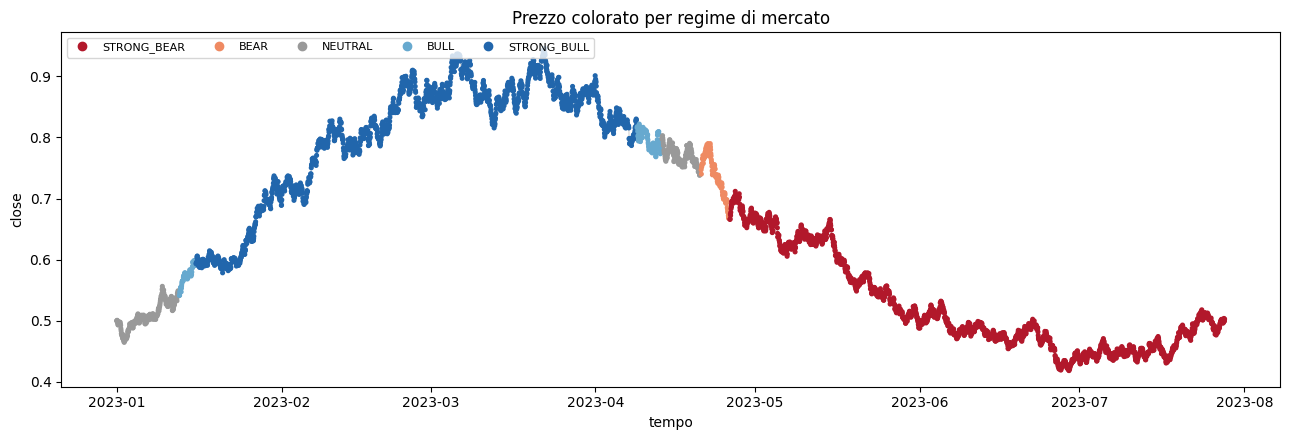

In [10]:
try:
    import matplotlib.pyplot as plt

    seg = out.iloc[:5000]
    colors = {"STRONG_BEAR": "#b2182b", "BEAR": "#ef8a62", "NEUTRAL": "#999999",
              "BULL": "#67a9cf", "STRONG_BULL": "#2166ac"}

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(seg["open_dt"], seg["close"], color="lightgray", lw=0.8, zorder=1)
    ax.scatter(seg["open_dt"], seg["close"], s=7, zorder=2,
               c=seg["regime"].astype(str).map(colors))
    handles = [plt.Line2D([0], [0], marker="o", ls="", mfc=c, mec=c, label=l)
               for l, c in colors.items()]
    ax.legend(handles=handles, ncol=5, loc="upper left", fontsize=8)
    ax.set_title("Prezzo colorato per regime di mercato")
    ax.set_xlabel("tempo"); ax.set_ylabel("close")
    plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib non installato — cella di grafico saltata")

---

**Riepilogo.** Il Market Context Module decide gli span EMA dai dati (Hurst/OU),
classifica ogni barra in cinque regimi ordinati e li espone come `regime` + `regime_stable`
sulla KPI Table (o via `regime_table()` per il join). Il *modo di taglio* (`fixed`/`balanced`),
la *causalità* (`global`/`expanding`) e l'*unità della finestra* (`bar`/`day`) sono configurabili,
con tracciabilità completa in `get_config()`.

*Market Context Module — FORGE (Feature-Oriented Rule Generation Engine).*